<center><img src="img/header_gr13_outlier_anomalies.jpg"></center>

# Airbnb Listings
The dataset contains information on **17,432 Airbnb listings in Bangkok**. Each row represents a listing with details such as coordinates, neighborhood, host id, price per night, number of reviews, and so on. 

Source: [InsideAirbnb](http://insideairbnb.com)

## Data Dictionary

| Column                            | Explanation                                                                                                                                                                                        |
| --------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| id                                | Airbnb's unique identifier for the listing                                                                                                                                                         |
| name                              |                                                                                                                                                                                                    |
| host\_id                          |                                                                                                                                                                                                    |
| host\_name                        |                                                                                                                                                                                                    |
| neighbourhood\_group              | The neighbourhood group as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles.                                                        |
| neighbourhood                     | The neighbourhood as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles.                                                              |
| latitude                          | Uses the World Geodetic System (WGS84) projection for latitude and longitude.                                                                                                                      |
| longitude                         | Uses the World Geodetic System (WGS84) projection for latitude and longitude.                                                                                                                      |
| room\_type                        |                                                                                                                                                                                                    |
| price                             | daily price in local currency. Note, $ sign may be used despite locale                                                                                                                             |
| minimum\_nights                   | minimum number of night stay for the listing (calendar rules may be different)                                                                                                                     |
| number\_of\_reviews               | The number of reviews the listing has                                                                                                                                                              |
| last\_review                      | The date of the last/newest review                                                                                                                                                                 |
| calculated\_host\_listings\_count | The number of listings the host has in the current scrape, in the city/region geography.                                                                                                           |
| availability\_365                 | avaliability\_x. The availability of the listing x days in the future as determined by the calendar. Note a listing may be available because it has been booked by a guest or blocked by the host. |
| number\_of\_reviews\_ltm          | The number of reviews the listing has (in the last 12 months)                                                                                                                                      |
| license                           |                                                                                                                                                                                                    |

The data for each city was compiled by [InsideAirbnb](http://insideairbnb.com) between October and November 2021.

[Source](http://insideairbnb.com/get-the-data.html) and [license](https://creativecommons.org/licenses/by/4.0/) of dataset. 

In [1]:
#CELL 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

df = pd.read_csv("listings_bangkok.csv")

print(list(df.columns))
prices = df['price']

print(prices.describe())

['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']
count     17431.000000
mean       2131.233779
std        6871.484717
min           0.000000
25%         710.500000
50%        1100.000000
75%        1900.000000
max      331104.000000
Name: price, dtype: float64


<center><img src="img/univariate.jpg"></center>
<h1 style="font-weight: bold;"> <center>Univariate outlier detection tools identify extreme data points within a single variable by analyzing its distribution, center, and spread. </center></h1> 

# CODE

<h1 style="font-weight: bold;"> <center>HISTOGRAM</center></h1> 
A Histogram is a graph that displays the frequency distribution of a single numerical variable by grouping data into "bins" (ranges).

**Role in Outlier Analysis:** It allows you to see the "shape" of your data. If most listings are priced between $\$500$ and $\$5,000$, but you see a tiny, isolated bar far to the right at $\$50,000$, that indicates a potential outlier.

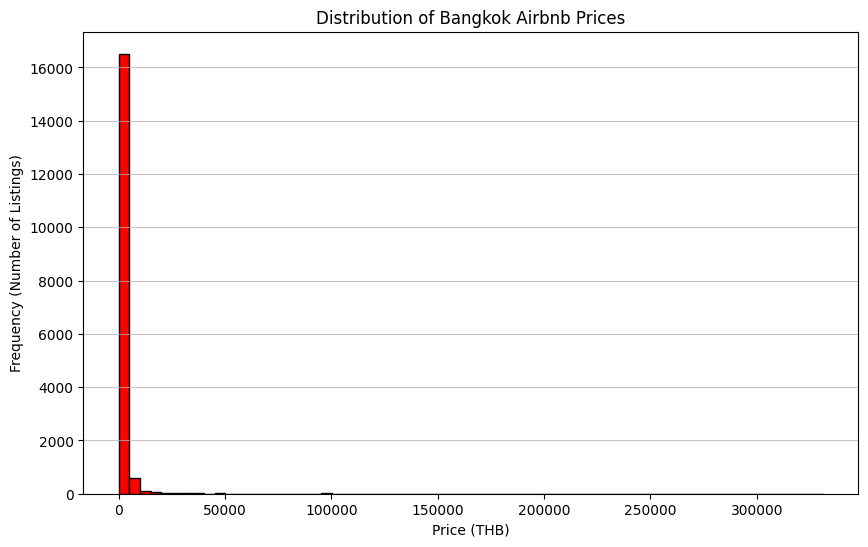

In [9]:
#CELL 2
n_bins = np.sqrt(len(prices))/2

n_bins = int(n_bins)

plt.figure(figsize=(10, 6))

# Added edge color to distinguish between bins
plt.hist(prices, bins=n_bins, color='red', edgecolor='black')

plt.title('Distribution of Bangkok Airbnb Prices')
plt.xlabel('Price (THB)')
plt.ylabel('Frequency (Number of Listings)')

plt.grid(axis='y', alpha=0.75)
plt.show()

<h1 style="font-weight: bold;"> <center>BOX PLOTS</center></h1> 

A Box Plot (or box-and-whisker plot) is a visual representation of the "Five-Number Summary": Minimum, First Quartile ($Q_{1}$), Median, Third Quartile ($Q_{3}$), and Maximum.

**Role in Outlier Analysis:** It is specifically designed to highlight outliers. Points that fall outside the "whiskers" are typically plotted individually as dots, signaling they are statistically distant from the rest of the data.

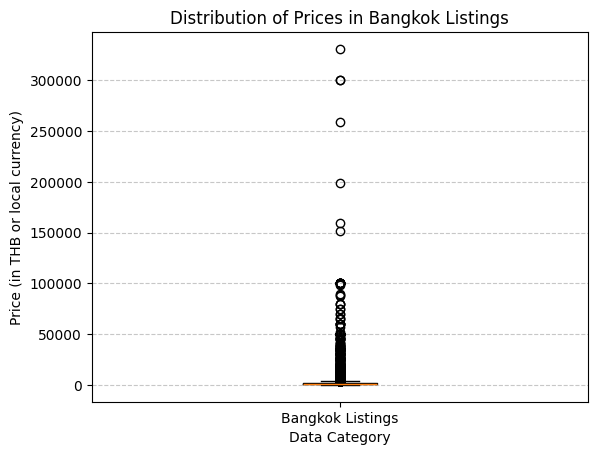

In [3]:
# CELL 3
plt.boxplot(prices, tick_labels=['Bangkok Listings'])

# Add the labels
plt.title("Distribution of Prices in Bangkok Listings")
plt.xlabel("Data Category")
plt.ylabel("Price (in THB or local currency)")

# Add a grid (Optional)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.ylim(0, 20000)

plt.show()

<center><img src="img/Boxplot.png"></center>

Source: <a href="https://discovery.cs.illinois.edu/learn/Exploratory-Data-Analysis/Quartiles-and-Box-Plots/">Data Science Discovery</a>

<h1 style="font-weight: bold;"> <center>Interquartile Range(IQR)</center></h1> 

The Interquartile Range (IQR) is a robust statistical method used to detect outliers by measuring the spread of the middle 50% of a dataset. Unlike the range or standard deviation, it is resistant to extreme values because it relies on quartiles rather than the mean. It measures of statistical dispersion, calculated as the difference between the 75th percentile ($Q_{3}$) and the 25th percentile ($Q_{1}$). 

Reference: <a href="https://medium.com/@pp1222001/outlier-detection-and-removal-using-the-iqr-method-6fab2954315d">Medium</a>

In [4]:
# CELL 4
# Calculate the 25th and 75th percentiles
q1 = prices.quantile(0.25)
q3 = prices.quantile(0.75)

# Find the IQR
IQR = q3 - q1
factor = 1.5

# Calculate the lower limit
lower_limit = q1 - (IQR * factor)

# Calculate the upper limit
upper_limit = q3 + (IQR * factor)

# Create a mask for values lower than lower_limit
is_lower = prices < lower_limit

# Create a mask for values higher than upper_limit
is_higher = prices > upper_limit

# Combine the masks to filter for outliers
outliers_is_higher = prices[is_higher]
outliers_is_lower = prices[is_lower]

# Count and print the number of outliers
print(f"Total outliers above the upper limit: {len(outliers_is_higher)}")
print(f"Total outliers below the lower limit: {len(outliers_is_lower)}")


Total outliers above the upper limit: 1553
Total outliers below the lower limit: 0


<h1 style="font-weight: bold;"> <center>SCATTERPLOT</center></h1> 
Scatterplots are effective visual tools for identifying outliers, data points that diverge significantly from the general pattern, trend, or cluster of the rest of the dataset.

**Role in Outlier Analysis:** Outliers appear as points far from the main cloud of data or regression line. They can represent errors, unique cases, or crucial unusual findings.

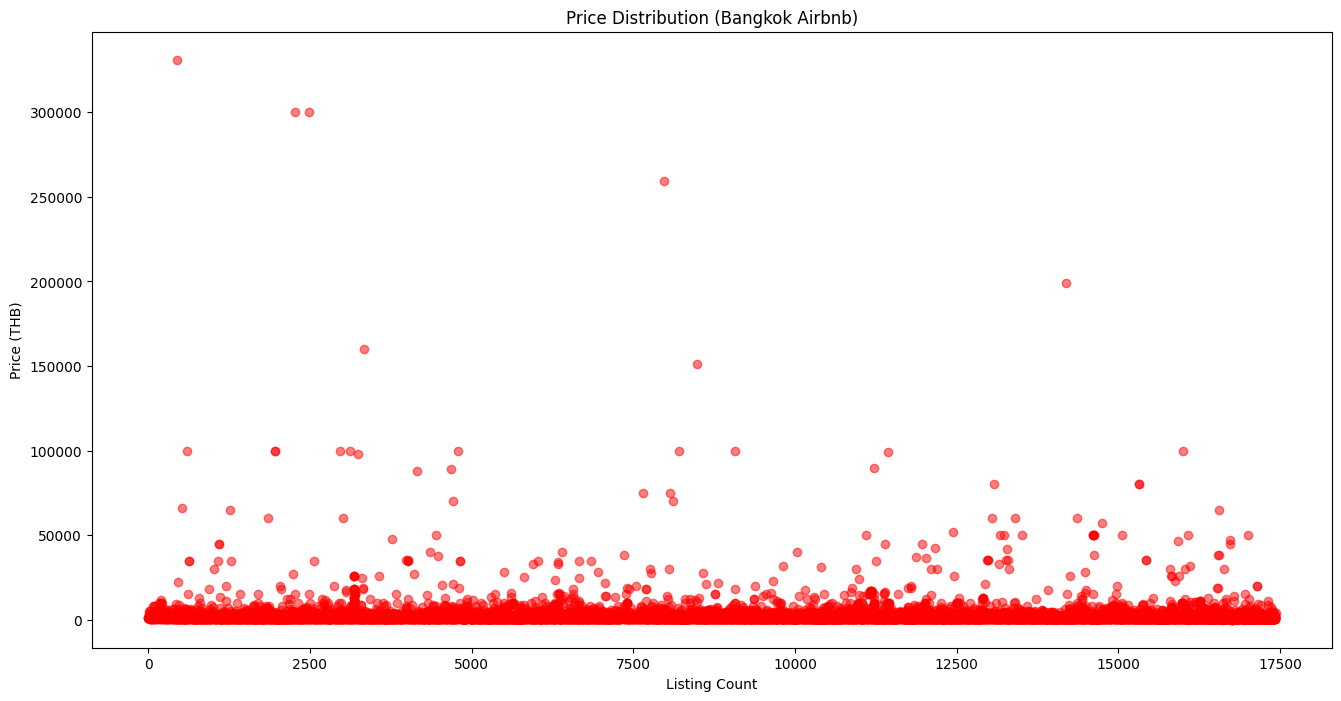

In [5]:
#CELL 5
#Sort the prices from lowest to highest
#prices = prices.sort_values().values
integers = range(len(prices))

plt.figure(figsize=(16, 8))
plt.scatter(integers, prices, c='red', alpha=0.5)
plt.title("Price Distribution (Bangkok Airbnb)")
plt.ylabel("Price (THB)")
plt.xlabel("Listing Count")
plt.show()

<h1 style="font-weight: bold;"> <center>Z-SCORE</center></h1> 

The Z-Score tells us how many standard deviations a price is from the average. A score of $3$ means the price is very far from the "norm." While common, this tool is sensitive. If we have one listing at $1,000,000$ THB, it will pull the average up and might make other real outliers look "normal."

In [ ]:
#CELL 6
# Find the zscores of prices
scores = zscore(prices)
print(scores[:50])  # Print the first 50 z-scores to check

# Check if the absolute values of scores are over 3
is_over_3 = np.abs(scores) > 3

# Use the mask to subset prices
outliers = scores[is_over_3]

print(f"Total outliers found: {len(outliers)}")

[-4.51492932e-02 -1.26793380e-01 -1.41492226e-01 -1.93738620e-01
 -1.93738620e-01 -4.51492932e-02 -2.26774641e-01 -9.30296933e-02
 -1.94320753e-01  6.36943519e-03 -1.77729976e-01 -1.89518159e-01
  2.68911204e-01 -1.41492226e-01  4.80225310e-01 -1.17188193e-01
 -6.91622598e-02 -1.36980699e-01 -1.66087325e-01 -1.79185307e-01
 -6.91622598e-02 -5.79562087e-02 -1.42802024e-01 -1.27084446e-01
 -6.91622598e-02 -1.65650726e-01  4.13716669e-01 -1.41492226e-01
  3.02217318e-03 -1.84861099e-01  6.36943519e-03 -3.25088837e-04
  5.13391727e-02  3.80956578e-02  9.95106391e-02 -2.03925939e-01
 -1.89663692e-01 -9.30296933e-02 -5.59187449e-02 -2.13822192e-01
 -2.35943228e-01 -1.71908650e-01 -1.35525368e-01  2.10261352e-01
 -1.51097413e-01 -2.08291933e-01 -1.94466286e-01 -2.08291933e-01
 -2.05381270e-01 -1.80640638e-01]
Total outliers found: 134
